In [3]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, recall_score, precision_score,
                              f1_score)
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
DATASET_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
IMAGE_SIZE   = (224, 224)   # EfficientNetB0 default input
BATCH_SIZE   = 64
CLASSES      = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
NUM_CLASSES  = len(CLASSES)

def load_dataset(dataset_path, classes, img_size):
    file_paths, labels = [], []
    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_path, class_name, "images")
        if not os.path.isdir(class_dir):
            class_dir = os.path.join(dataset_path, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                file_paths.append(os.path.join(class_dir, fname))
                labels.append(label_idx)
    return np.array(file_paths), np.array(labels)

file_paths, labels = load_dataset(DATASET_PATH, CLASSES, IMAGE_SIZE)
print(f"Total images loaded: {len(file_paths)}")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {np.sum(labels == i)} images")

Total images loaded: 21165
  COVID: 3616 images
  Normal: 10192 images
  Lung_Opacity: 6012 images
  Viral Pneumonia: 1345 images


In [5]:
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    file_paths, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels          # Stratified: preserves class proportions
)
print(f"Training set  : {len(X_train_paths)} images")
print(f"Validation set: {len(X_val_paths)} images")

# ---------------------------------------------------------------------------
# FIX 1 — Do NOT divide by 255 here.
# EfficientNetB0 includes a built-in Rescaling(1/255) + Normalization layer
# inside the model. Dividing by 255 in the pipeline AND letting the model
# rescale again would give pixel values near 0 (~0.004), causing very bad
# results regardless of how many layers are unfrozen.
# Feed raw float32 pixels in [0, 255] — the model handles normalization.
# The TP requirement (divide by 255) is satisfied internally by the model.
# ---------------------------------------------------------------------------
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)          # [0, 255] — EfficientNetB0 rescales internally
    return img, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, tf.cast(labels, tf.int32))
    )
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=2048, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train_paths, y_train, shuffle=True)
val_ds   = make_dataset(X_val_paths,   y_val,   shuffle=False)

Training set  : 14815 images
Validation set: 6350 images


I0000 00:00:1776726520.045743      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
final_results = {}

def evaluate_and_save(model, config_name, val_dataset, true_labels, train_time):
    print(f"\nEvaluating {config_name}...")

    y_pred_probs = model.predict(val_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # FIX 3 — Use macro averaging for all metrics (same as friend's version).
    # Macro treats every class equally, which is more appropriate for medical
    # data where minority classes (e.g. Viral Pneumonia) matter as much as Normal.
    acc         = accuracy_score(true_labels, y_pred)
    prec        = precision_score(true_labels, y_pred, average="macro", zero_division=0)
    rec         = recall_score(true_labels, y_pred, average="macro", zero_division=0)
    f1          = f1_score(true_labels, y_pred, average="macro", zero_division=0)
    sensitivity = rec   # sensitivity = macro recall (same value, no second call needed)

    final_results[config_name] = {
        "Accuracy"      : acc,
        "Precision"     : prec,
        "Recall"        : rec,
        "F1-Score"      : f1,
        "Sensitivity"   : sensitivity,
        "Train Time (s)": train_time
    }

    print(f"--- Results for {config_name} ---")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"F1-Score    : {f1:.4f}")
    print(f"Sensitivity : {sensitivity:.4f}")
    print(f"Train Time  : {train_time:.1f} seconds")
    print("\nClassification Report:")
    print(classification_report(true_labels, y_pred, target_names=CLASSES))

## Scenario 1 — FC only (entire base frozen)

In [7]:
def build_model_fc_only():
    print("Building Model: Top layers (FC) only.")

    base = EfficientNetB0(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation="relu", name="fc_1024")(x)
    x = layers.Dense(512,  activation="relu", name="fc_512")(x)
    output = layers.Dense(NUM_CLASSES, activation="softmax", name="fc_out")(x)

    model = Model(inputs=base.input, outputs=output)

    # Freeze entire base model
    base.trainable = False

    trainable_params = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    total_params     = model.count_params()
    print(f"Total params      : {total_params:,}")
    print(f"Trainable params  : {trainable_params:,}")
    print(f"Frozen params     : {total_params - trainable_params:,}")
    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [8]:
model_fc = build_model_fc_only()

start_time = time.time()
history_fc = model_fc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=1
)
elapsed_time_fc = time.time() - start_time

evaluate_and_save(
    model=model_fc,
    config_name="FC Only",
    val_dataset=val_ds,
    true_labels=y_val,
    train_time=elapsed_time_fc
)

Building Model: Top layers (FC) only.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params      : 5,888,167
Trainable params  : 1,838,596
Frozen params     : 4,049,571


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,888,167 (22.46 MB)

 Trainable params: 1,838,596 (7.01 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20


I0000 00:00:1776726540.759061     134 service.cc:152] XLA service 0x7de3d0411ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776726540.759097     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776726542.924342     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776726553.800837     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


232/232 ━━━━━━━━━━━━━━━━━━━━ 118s 382ms/step - accuracy: 0.7679 - loss: 0.6079 - val_accuracy: 0.8641 - val_loss: 0.3678
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.8774 - loss: 0.3226 - val_accuracy: 0.9005 - val_loss: 0.2694
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.8993 - loss: 0.2679 - val_accuracy: 0.9049 - val_loss: 0.2498
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.9055 - loss: 0.2492 - val_accuracy: 0.9085 - val_loss: 0.2452
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.9109 - loss: 0.2409 - val_accuracy: 0.9112 - val_loss: 0.2411
Epoch 6/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9238 - loss: 0.2078 - val_accuracy: 0.9068 - val_loss: 0.2559
Epoch 7/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.9200 - loss: 0.2121 - val_accuracy: 0.9014 - val_loss: 0.2736
Epoch 8/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - accuracy: 0.9275 - loss: 0.2000 - va

## Scenario 2 — Last 1 Conv2D layer + FC

In [9]:
def build_model_1conv_fc():
    print("Building Model: Last 1 Conv2D layer + FC.")

    base = EfficientNetB0(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation="relu", name="fc_1024")(x)
    x = layers.Dense(512,  activation="relu", name="fc_512")(x)
    output = layers.Dense(NUM_CLASSES, activation="softmax", name="fc_out")(x)

    model = Model(inputs=base.input, outputs=output)

    # FIX 2 — Explicit Conv2D layer selection (architecture-agnostic).
    # Freeze all base layers first, then unfreeze only the last 1 Conv2D.
    # This is precise: regardless of block structure, exactly 1 conv is trained.
    base.trainable = True
    for layer in base.layers:
        layer.trainable = False
    conv_layers = [l for l in base.layers if isinstance(l, layers.Conv2D)]
    for layer in conv_layers[-1:]:
        layer.trainable = True
    print(f"Unfrozen Conv2D layers: {[l.name for l in conv_layers[-1:]]}")

    trainable_params = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    total_params     = model.count_params()
    print(f"Total params      : {total_params:,}")
    print(f"Trainable params  : {trainable_params:,}")
    print(f"Frozen params     : {total_params - trainable_params:,}")
    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [10]:
model_1conv_fc = build_model_1conv_fc()

start_time = time.time()
history_1conv_fc = model_1conv_fc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=1
)
elapsed_time_1conv_fc = time.time() - start_time

evaluate_and_save(
    model=model_1conv_fc,
    config_name="1 Conv + FC",
    val_dataset=val_ds,
    true_labels=y_val,
    train_time=elapsed_time_1conv_fc
)

Building Model: Last 1 Conv2D layer + FC.
Unfrozen Conv2D layers: ['top_conv']
Total params      : 5,888,167
Trainable params  : 2,248,196
Frozen params     : 3,639,971


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,888,167 (22.46 MB)

 Trainable params: 2,248,196 (8.58 MB)

 Non-trainable params: 3,639,971 (13.89 MB)

Epoch 1/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 66s 197ms/step - accuracy: 0.7762 - loss: 0.5787 - val_accuracy: 0.8865 - val_loss: 0.3008
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.8990 - loss: 0.2765 - val_accuracy: 0.8954 - val_loss: 0.2967
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 109ms/step - accuracy: 0.9178 - loss: 0.2222 - val_accuracy: 0.9135 - val_loss: 0.2388
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9312 - loss: 0.1960 - val_accuracy: 0.9265 - val_loss: 0.2052
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 108ms/step - accuracy: 0.9403 - loss: 0.1629 - val_accuracy: 0.9072 - val_loss: 0.2552
Epoch 6/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 109ms/step - accuracy: 0.9456 - loss: 0.1512 - val_accuracy: 0.9044 - val_loss: 0.3059
Epoch 7/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9502 - loss: 0.1360 - val_accuracy: 0.9167 - val_loss: 0.2235
Epoch 8/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.9478 - loss: 0

## Scenario 3 — Last 2 Conv2D layers + FC

In [11]:
def build_model_2conv_fc():
    print("Building Model: Last 2 Conv2D layers + FC.")

    base = EfficientNetB0(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

[3]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, recall_score, precision_score,
                              f1_score)
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")
TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
￼add Code￼add Markdown
[4]:
DATASET_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
IMAGE_SIZE   = (224, 224)   # EfficientNetB0 default input
BATCH_SIZE   = 64
CLASSES      = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
NUM_CLASSES  = len(CLASSES)

def load_dataset(dataset_path, classes, img_size):
    file_paths, labels = [], []
    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_path, class_name, "images")
        if not os.path.isdir(class_dir):
            class_dir = os.path.join(dataset_path, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                file_paths.append(os.path.join(class_dir, fname))
                labels.append(label_idx)
    return np.array(file_paths), np.array(labels)

file_paths, labels = load_dataset(DATASET_PATH, CLASSES, IMAGE_SIZE)
print(f"Total images loaded: {len(file_paths)}")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {np.sum(labels == i)} images")
Total images loaded: 21165
  COVID: 3616 images
  Normal: 10192 images
  Lung_Opacity: 6012 images
  Viral Pneumonia: 1345 images
￼add Code￼add Markdown
[5]:
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    file_paths, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels          # Stratified: preserves class proportions
)
print(f"Training set  : {len(X_train_paths)} images")
print(f"Validation set: {len(X_val_paths)} images")

# ---------------------------------------------------------------------------
# FIX 1 — Do NOT divide by 255 here.
# EfficientNetB0 includes a built-in Rescaling(1/255) + Normalization layer
# inside the model. Dividing by 255 in the pipeline AND letting the model
# rescale again would give pixel values near 0 (~0.004), causing very bad
# results regardless of how many layers are unfrozen.
# Feed raw float32 pixels in [0, 255] — the model handles normalization.
# The TP requirement (divide by 255) is satisfied internally by the model.
# ---------------------------------------------------------------------------
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)          # [0, 255] — EfficientNetB0 rescales internally
    return img, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, tf.cast(labels, tf.int32))
    )
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=2048, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train_paths, y_train, shuffle=True)
val_ds   = make_dataset(X_val_paths,   y_val,   shuffle=False)
Training set  : 14815 images
Validation set: 6350 images
I0000 00:00:1776726520.045743      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
￼add Code￼add Markdown
[6]:
final_results = {}

def evaluate_and_save(model, config_name, val_dataset, true_labels, train_time):
    print(f"\nEvaluating {config_name}...")

    y_pred_probs = model.predict(val_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # FIX 3 — Use macro averaging for all metrics (same as friend's version).
    # Macro treats every class equally, which is more appropriate for medical
    # data where minority classes (e.g. Viral Pneumonia) matter as much as Normal.
    acc         = accuracy_score(true_labels, y_pred)
    prec        = precision_score(true_labels, y_pred, average="macro", zero_division=0)
    rec         = recall_score(true_labels, y_pred, average="macro", zero_division=0)
    f1          = f1_score(true_labels, y_pred, average="macro", zero_division=0)
    sensitivity = rec   # sensitivity = macro recall (same value, no second call needed)

    final_results[config_name] = {
        "Accuracy"      : acc,
        "Precision"     : prec,
        "Recall"        : rec,
        "F1-Score"      : f1,
        "Sensitivity"   : sensitivity,
        "Train Time (s)": train_time
    }

    print(f"--- Results for {config_name} ---")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"F1-Score    : {f1:.4f}")
    print(f"Sensitivity : {sensitivity:.4f}")
    print(f"Train Time  : {train_time:.1f} seconds")
    print("\nClassification Report:")
    print(classification_report(true_labels, y_pred, target_names=CLASSES))
￼add Code￼add Markdown
Scenario 1 — FC only (entire base frozen)
￼add Code￼add Markdown
[7]:
def build_model_fc_only():
    print("Building Model: Top layers (FC) only.")

    base = EfficientNetB0(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation="relu", name="fc_1024")(x)
    x = layers.Dense(512,  activation="relu", name="fc_512")(x)
    output = layers.Dense(NUM_CLASSES, activation="softmax", name="fc_out")(x)

    model = Model(inputs=base.input, outputs=output)

    # Freeze entire base model
    base.trainable = False

    trainable_params = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    total_params     = model.count_params()
    print(f"Total params      : {total_params:,}")
    print(f"Trainable params  : {trainable_params:,}")
    print(f"Frozen params     : {total_params - trainable_params:,}")
    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
￼add Code￼add Markdown
[8]:
model_fc = build_model_fc_only()

start_time = time.time()
history_fc = model_fc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=1
)
elapsed_time_fc = time.time() - start_time

evaluate_and_save(
    model=model_fc,
    config_name="FC Only",
    val_dataset=val_ds,
    true_labels=y_val,
    train_time=elapsed_time_fc
)
Building Model: Top layers (FC) only.
Downloading data from https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params      : 5,888,167
Trainable params  : 1,838,596
Frozen params     : 4,049,571
Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 112, 112,  │      1,536 │ block1a_project_… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 112, 112,  │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 112, 112,  │          0 │ block2a_expand_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_dwconv_pad  │ (None, 113, 113,  │          0 │ block2a_expand_a… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_dwconv      │ (None, 56, 56,    │        864 │ block2a_dwconv_p… │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_bn          │ (None, 56, 56,    │        384 │ block2a_dwconv[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_activation  │ (None, 56, 56,    │          0 │ block2a_bn[0][0]  │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_squeeze  │ (None, 96)        │          0 │ block2a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_reshape  │ (None, 1, 1, 96)  │          0 │ block2a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_reduce   │ (None, 1, 1, 4)   │        388 │ block2a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_expand   │ (None, 1, 1, 96)  │        480 │ block2a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_excite   │ (None, 56, 56,    │          0 │ block2a_activati… │
│ (Multiply)          │ 96)               │            │ block2a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,304 │ block2a_se_excit… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │         96 │ block2a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │      3,456 │ block2a_project_… │
│ (Conv2D)            │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        576 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b… │
│ (Activation)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_dwconv      │ (None, 56, 56,    │      1,296 │ block2b_expand_a… │
│ (DepthwiseConv2D)   │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_bn          │ (None, 56, 56,    │        576 │ block2b_dwconv[0… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_activation  │ (None, 56, 56,    │          0 │ block2b_bn[0][0]  │
│ (Activation)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_squeeze  │ (None, 144)       │          0 │ block2b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_reshape  │ (None, 1, 1, 144) │          0 │ block2b_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_reduce   │ (None, 1, 1, 6)   │        870 │ block2b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_expand   │ (None, 1, 1, 144) │      1,008 │ block2b_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_excite   │ (None, 56, 56,    │          0 │ block2b_activati… │
│ (Multiply)          │ 144)              │            │ block2b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_project_co… │ (None, 56, 56,    │      3,456 │ block2b_se_excit… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_project_bn  │ (None, 56, 56,    │         96 │ block2b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_drop        │ (None, 56, 56,    │          0 │ block2b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_add (Add)   │ (None, 56, 56,    │          0 │ block2b_drop[0][… │
│                     │ 24)               │            │ block2a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_expand_conv │ (None, 56, 56,    │      3,456 │ block2b_add[0][0] │
│ (Conv2D)            │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_expand_bn   │ (None, 56, 56,    │        576 │ block3a_expand_c… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_expand_act… │ (None, 56, 56,    │          0 │ block3a_expand_b… │
│ (Activation)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_dwconv_pad  │ (None, 59, 59,    │          0 │ block3a_expand_a… │
│ (ZeroPadding2D)     │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_dwconv      │ (None, 28, 28,    │      3,600 │ block3a_dwconv_p… │
│ (DepthwiseConv2D)   │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_bn          │ (None, 28, 28,    │        576 │ block3a_dwconv[0… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_activation  │ (None, 28, 28,    │          0 │ block3a_bn[0][0]  │
│ (Activation)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_squeeze  │ (None, 144)       │          0 │ block3a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_reshape  │ (None, 1, 1, 144) │          0 │ block3a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_reduce   │ (None, 1, 1, 6)   │        870 │ block3a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_expand   │ (None, 1, 1, 144) │      1,008 │ block3a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_excite   │ (None, 28, 28,    │          0 │ block3a_activati… │
│ (Multiply)          │ 144)              │            │ block3a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_project_co… │ (None, 28, 28,    │      5,760 │ block3a_se_excit… │
│ (Conv2D)            │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_project_bn  │ (None, 28, 28,    │        160 │ block3a_project_… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_expand_conv │ (None, 28, 28,    │      9,600 │ block3a_project_… │
│ (Conv2D)            │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_expand_bn   │ (None, 28, 28,    │        960 │ block3b_expand_c… │
│ (BatchNormalizatio… │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_expand_act… │ (None, 28, 28,    │          0 │ block3b_expand_b… │
│ (Activation)        │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_dwconv      │ (None, 28, 28,    │      6,000 │ block3b_expand_a… │
│ (DepthwiseConv2D)   │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_bn          │ (None, 28, 28,    │        960 │ block3b_dwconv[0… │
│ (BatchNormalizatio… │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_activation  │ (None, 28, 28,    │          0 │ block3b_bn[0][0]  │
│ (Activation)        │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_squeeze  │ (None, 240)       │          0 │ block3b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_reshape  │ (None, 1, 1, 240) │          0 │ block3b_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_reduce   │ (None, 1, 1, 10)  │      2,410 │ block3b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_expand   │ (None, 1, 1, 240) │      2,640 │ block3b_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_excite   │ (None, 28, 28,    │          0 │ block3b_activati… │
│ (Multiply)          │ 240)              │            │ block3b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_project_co… │ (None, 28, 28,    │      9,600 │ block3b_se_excit… │
│ (Conv2D)            │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_project_bn  │ (None, 28, 28,    │        160 │ block3b_project_… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_drop        │ (None, 28, 28,    │          0 │ block3b_project_… │
│ (Dropout)           │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_add (Add)   │ (None, 28, 28,    │          0 │ block3b_drop[0][… │
│                     │ 40)               │            │ block3a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_expand_conv │ (None, 28, 28,    │      9,600 │ block3b_add[0][0] │
│ (Conv2D)            │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_expand_bn   │ (None, 28, 28,    │        960 │ block4a_expand_c… │
│ (BatchNormalizatio… │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_expand_act… │ (None, 28, 28,    │          0 │ block4a_expand_b… │
│ (Activation)        │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_dwconv_pad  │ (None, 29, 29,    │          0 │ block4a_expand_a… │
│ (ZeroPadding2D)     │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_dwconv      │ (None, 14, 14,    │      2,160 │ block4a_dwconv_p… │
│ (DepthwiseConv2D)   │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_bn          │ (None, 14, 14,    │        960 │ block4a_dwconv[0… │
│ (BatchNormalizatio… │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_activation  │ (None, 14, 14,    │          0 │ block4a_bn[0][0]  │
│ (Activation)        │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_squeeze  │ (None, 240)       │          0 │ block4a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_reshape  │ (None, 1, 1, 240) │          0 │ block4a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_reduce   │ (None, 1, 1, 10)  │      2,410 │ block4a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_expand   │ (None, 1, 1, 240) │      2,640 │ block4a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_excite   │ (None, 14, 14,    │          0 │ block4a_activati… │
│ (Multiply)          │ 240)              │            │ block4a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_project_co… │ (None, 14, 14,    │     19,200 │ block4a_se_excit… │
│ (Conv2D)            │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_project_bn  │ (None, 14, 14,    │        320 │ block4a_project_… │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_expand_conv │ (None, 14, 14,    │     38,400 │ block4a_project_… │
│ (Conv2D)            │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_expand_bn   │ (None, 14, 14,    │      1,920 │ block4b_expand_c… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_expand_act… │ (None, 14, 14,    │          0 │ block4b_expand_b… │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_dwconv      │ (None, 14, 14,    │      4,320 │ block4b_expand_a… │
│ (DepthwiseConv2D)   │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_bn          │ (None, 14, 14,    │      1,920 │ block4b_dwconv[0… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_activation  │ (None, 14, 14,    │          0 │ block4b_bn[0][0]  │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_squeeze  │ (None, 480)       │          0 │ block4b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_reshape  │ (None, 1, 1, 480) │          0 │ block4b_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_reduce   │ (None, 1, 1, 20)  │      9,620 │ block4b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_expand   │ (None, 1, 1, 480) │     10,080 │ block4b_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_excite   │ (None, 14, 14,    │          0 │ block4b_activati… │
│ (Multiply)          │ 480)              │            │ block4b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_project_co… │ (None, 14, 14,    │     38,400 │ block4b_se_excit… │
│ (Conv2D)            │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_project_bn  │ (None, 14, 14,    │        320 │ block4b_project_… │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_drop        │ (None, 14, 14,    │          0 │ block4b_project_… │
│ (Dropout)           │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_add (Add)   │ (None, 14, 14,    │          0 │ block4b_drop[0][… │
│                     │ 80)               │            │ block4a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_expand_conv │ (None, 14, 14,    │     38,400 │ block4b_add[0][0] │
│ (Conv2D)            │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_expand_bn   │ (None, 14, 14,    │      1,920 │ block4c_expand_c… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_expand_act… │ (None, 14, 14,    │          0 │ block4c_expand_b… │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_dwconv      │ (None, 14, 14,    │      4,320 │ block4c_expand_a… │
│ (DepthwiseConv2D)   │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_bn          │ (None, 14, 14,    │      1,920 │ block4c_dwconv[0… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_activation  │ (None, 14, 14,    │          0 │ block4c_bn[0][0]  │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_squeeze  │ (None, 480)       │          0 │ block4c_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_reshape  │ (None, 1, 1, 480) │          0 │ block4c_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_reduce   │ (None, 1, 1, 20)  │      9,620 │ block4c_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_expand   │ (None, 1, 1, 480) │     10,080 │ block4c_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_excite   │ (None, 14, 14,    │          0 │ block4c_activati… │
│ (Multiply)          │ 480)              │            │ block4c_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_project_co… │ (None, 14, 14,    │     38,400 │ block4c_se_excit… │
│ (Conv2D)            │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_project_bn  │ (None, 14, 14,    │        320 │ block4c_project_… │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_drop        │ (None, 14, 14,    │          0 │ block4c_project_… │
│ (Dropout)           │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_add (Add)   │ (None, 14, 14,    │          0 │ block4c_drop[0][… │
│                     │ 80)               │            │ block4b_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_expand_conv │ (None, 14, 14,    │     38,400 │ block4c_add[0][0] │
│ (Conv2D)            │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_expand_bn   │ (None, 14, 14,    │      1,920 │ block5a_expand_c… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_expand_act… │ (None, 14, 14,    │          0 │ block5a_expand_b… │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_dwconv      │ (None, 14, 14,    │     12,000 │ block5a_expand_a… │
│ (DepthwiseConv2D)   │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_bn          │ (None, 14, 14,    │      1,920 │ block5a_dwconv[0… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_activation  │ (None, 14, 14,    │          0 │ block5a_bn[0][0]  │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_squeeze  │ (None, 480)       │          0 │ block5a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_reshape  │ (None, 1, 1, 480) │          0 │ block5a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_reduce   │ (None, 1, 1, 20)  │      9,620 │ block5a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_expand   │ (None, 1, 1, 480) │     10,080 │ block5a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_excite   │ (None, 14, 14,    │          0 │ block5a_activati… │
│ (Multiply)          │ 480)              │            │ block5a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_project_co… │ (None, 14, 14,    │     53,760 │ block5a_se_excit… │
│ (Conv2D)            │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_project_bn  │ (None, 14, 14,    │        448 │ block5a_project_… │
│ (BatchNormalizatio… │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_expand_conv │ (None, 14, 14,    │     75,264 │ block5a_project_… │
│ (Conv2D)            │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_expand_bn   │ (None, 14, 14,    │      2,688 │ block5b_expand_c… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_expand_act… │ (None, 14, 14,    │          0 │ block5b_expand_b… │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_dwconv      │ (None, 14, 14,    │     16,800 │ block5b_expand_a… │
│ (DepthwiseConv2D)   │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_bn          │ (None, 14, 14,    │      2,688 │ block5b_dwconv[0… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_activation  │ (None, 14, 14,    │          0 │ block5b_bn[0][0]  │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_squeeze  │ (None, 672)       │          0 │ block5b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_reshape  │ (None, 1, 1, 672) │          0 │ block5b_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_reduce   │ (None, 1, 1, 28)  │     18,844 │ block5b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_expand   │ (None, 1, 1, 672) │     19,488 │ block5b_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_excite   │ (None, 14, 14,    │          0 │ block5b_activati… │
│ (Multiply)          │ 672)              │            │ block5b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_project_co… │ (None, 14, 14,    │     75,264 │ block5b_se_excit… │
│ (Conv2D)            │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_project_bn  │ (None, 14, 14,    │        448 │ block5b_project_… │
│ (BatchNormalizatio… │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_drop        │ (None, 14, 14,    │          0 │ block5b_project_… │
│ (Dropout)           │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_add (Add)   │ (None, 14, 14,    │          0 │ block5b_drop[0][… │
│                     │ 112)              │            │ block5a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_expand_conv │ (None, 14, 14,    │     75,264 │ block5b_add[0][0] │
│ (Conv2D)            │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_expand_bn   │ (None, 14, 14,    │      2,688 │ block5c_expand_c… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_expand_act… │ (None, 14, 14,    │          0 │ block5c_expand_b… │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_dwconv      │ (None, 14, 14,    │     16,800 │ block5c_expand_a… │
│ (DepthwiseConv2D)   │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_bn          │ (None, 14, 14,    │      2,688 │ block5c_dwconv[0… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_activation  │ (None, 14, 14,    │          0 │ block5c_bn[0][0]  │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_squeeze  │ (None, 672)       │          0 │ block5c_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_reshape  │ (None, 1, 1, 672) │          0 │ block5c_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_reduce   │ (None, 1, 1, 28)  │     18,844 │ block5c_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_expand   │ (None, 1, 1, 672) │     19,488 │ block5c_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_excite   │ (None, 14, 14,    │          0 │ block5c_activati… │
│ (Multiply)          │ 672)              │            │ block5c_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_project_co… │ (None, 14, 14,    │     75,264 │ block5c_se_excit… │
│ (Conv2D)            │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_project_bn  │ (None, 14, 14,    │        448 │ block5c_project_… │
│ (BatchNormalizatio… │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_drop        │ (None, 14, 14,    │          0 │ block5c_project_… │
│ (Dropout)           │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_add (Add)   │ (None, 14, 14,    │          0 │ block5c_drop[0][… │
│                     │ 112)              │            │ block5b_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_expand_conv │ (None, 14, 14,    │     75,264 │ block5c_add[0][0] │
│ (Conv2D)            │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_expand_bn   │ (None, 14, 14,    │      2,688 │ block6a_expand_c… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_expand_act… │ (None, 14, 14,    │          0 │ block6a_expand_b… │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_dwconv_pad  │ (None, 17, 17,    │          0 │ block6a_expand_a… │
│ (ZeroPadding2D)     │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_dwconv      │ (None, 7, 7, 672) │     16,800 │ block6a_dwconv_p… │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_bn          │ (None, 7, 7, 672) │      2,688 │ block6a_dwconv[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_activation  │ (None, 7, 7, 672) │          0 │ block6a_bn[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_squeeze  │ (None, 672)       │          0 │ block6a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_reshape  │ (None, 1, 1, 672) │          0 │ block6a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_reduce   │ (None, 1, 1, 28)  │     18,844 │ block6a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_expand   │ (None, 1, 1, 672) │     19,488 │ block6a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_excite   │ (None, 7, 7, 672) │          0 │ block6a_activati… │
│ (Multiply)          │                   │            │ block6a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_project_co… │ (None, 7, 7, 192) │    129,024 │ block6a_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_project_bn  │ (None, 7, 7, 192) │        768 │ block6a_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_expand_conv │ (None, 7, 7,      │    221,184 │ block6a_project_… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_expand_bn   │ (None, 7, 7,      │      4,608 │ block6b_expand_c… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_expand_act… │ (None, 7, 7,      │          0 │ block6b_expand_b… │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_dwconv      │ (None, 7, 7,      │     28,800 │ block6b_expand_a… │
│ (DepthwiseConv2D)   │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_bn          │ (None, 7, 7,      │      4,608 │ block6b_dwconv[0… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_activation  │ (None, 7, 7,      │          0 │ block6b_bn[0][0]  │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_squeeze  │ (None, 1152)      │          0 │ block6b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_reshape  │ (None, 1, 1,      │          0 │ block6b_se_squee… │
│ (Reshape)           │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_reduce   │ (None, 1, 1, 48)  │     55,344 │ block6b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_expand   │ (None, 1, 1,      │     56,448 │ block6b_se_reduc… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_excite   │ (None, 7, 7,      │          0 │ block6b_activati… │
│ (Multiply)          │ 1152)             │            │ block6b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_project_co… │ (None, 7, 7, 192) │    221,184 │ block6b_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_project_bn  │ (None, 7, 7, 192) │        768 │ block6b_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_drop        │ (None, 7, 7, 192) │          0 │ block6b_project_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_add (Add)   │ (None, 7, 7, 192) │          0 │ block6b_drop[0][… │
│                     │                   │            │ block6a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_expand_conv │ (None, 7, 7,      │    221,184 │ block6b_add[0][0] │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_expand_bn   │ (None, 7, 7,      │      4,608 │ block6c_expand_c… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_expand_act… │ (None, 7, 7,      │          0 │ block6c_expand_b… │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_dwconv      │ (None, 7, 7,      │     28,800 │ block6c_expand_a… │
│ (DepthwiseConv2D)   │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_bn          │ (None, 7, 7,      │      4,608 │ block6c_dwconv[0… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_activation  │ (None, 7, 7,      │          0 │ block6c_bn[0][0]  │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_squeeze  │ (None, 1152)      │          0 │ block6c_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_reshape  │ (None, 1, 1,      │          0 │ block6c_se_squee… │
│ (Reshape)           │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_reduce   │ (None, 1, 1, 48)  │     55,344 │ block6c_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_expand   │ (None, 1, 1,      │     56,448 │ block6c_se_reduc… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_excite   │ (None, 7, 7,      │          0 │ block6c_activati… │
│ (Multiply)          │ 1152)             │            │ block6c_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_project_co… │ (None, 7, 7, 192) │    221,184 │ block6c_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_project_bn  │ (None, 7, 7, 192) │        768 │ block6c_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_drop        │ (None, 7, 7, 192) │          0 │ block6c_project_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_add (Add)   │ (None, 7, 7, 192) │          0 │ block6c_drop[0][… │
│                     │                   │            │ block6b_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_expand_conv │ (None, 7, 7,      │    221,184 │ block6c_add[0][0] │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_expand_bn   │ (None, 7, 7,      │      4,608 │ block6d_expand_c… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_expand_act… │ (None, 7, 7,      │          0 │ block6d_expand_b… │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_dwconv      │ (None, 7, 7,      │     28,800 │ block6d_expand_a… │
│ (DepthwiseConv2D)   │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_bn          │ (None, 7, 7,      │      4,608 │ block6d_dwconv[0… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_activation  │ (None, 7, 7,      │          0 │ block6d_bn[0][0]  │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_squeeze  │ (None, 1152)      │          0 │ block6d_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_reshape  │ (None, 1, 1,      │          0 │ block6d_se_squee… │
│ (Reshape)           │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_reduce   │ (None, 1, 1, 48)  │     55,344 │ block6d_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_expand   │ (None, 1, 1,      │     56,448 │ block6d_se_reduc… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_excite   │ (None, 7, 7,      │          0 │ block6d_activati… │
│ (Multiply)          │ 1152)             │            │ block6d_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_project_co… │ (None, 7, 7, 192) │    221,184 │ block6d_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_project_bn  │ (None, 7, 7, 192) │        768 │ block6d_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_drop        │ (None, 7, 7, 192) │          0 │ block6d_project_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_add (Add)   │ (None, 7, 7, 192) │          0 │ block6d_drop[0][… │
│                     │                   │            │ block6c_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_expand_conv │ (None, 7, 7,      │    221,184 │ block6d_add[0][0] │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_expand_bn   │ (None, 7, 7,      │      4,608 │ block7a_expand_c… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_expand_act… │ (None, 7, 7,      │          0 │ block7a_expand_b… │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_dwconv      │ (None, 7, 7,      │     10,368 │ block7a_expand_a… │
│ (DepthwiseConv2D)   │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_bn          │ (None, 7, 7,      │      4,608 │ block7a_dwconv[0… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_activation  │ (None, 7, 7,      │          0 │ block7a_bn[0][0]  │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_squeeze  │ (None, 1152)      │          0 │ block7a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_reshape  │ (None, 1, 1,      │          0 │ block7a_se_squee… │
│ (Reshape)           │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_reduce   │ (None, 1, 1, 48)  │     55,344 │ block7a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_expand   │ (None, 1, 1,      │     56,448 │ block7a_se_reduc… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_excite   │ (None, 7, 7,      │          0 │ block7a_activati… │
│ (Multiply)          │ 1152)             │            │ block7a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_project_co… │ (None, 7, 7, 320) │    368,640 │ block7a_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_project_bn  │ (None, 7, 7, 320) │      1,280 │ block7a_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_conv (Conv2D)   │ (None, 7, 7,      │    409,600 │ block7a_project_… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_bn              │ (None, 7, 7,      │      5,120 │ top_conv[0][0]    │
│ (BatchNormalizatio… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_activation      │ (None, 7, 7,      │          0 │ top_bn[0][0]      │
│ (Activation)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ top_activation[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_1024 (Dense)     │ (None, 1024)      │  1,311,744 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_512 (Dense)      │ (None, 512)       │    524,800 │ fc_1024[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_out (Dense)      │ (None, 4)         │      2,052 │ fc_512[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘
 Total params: 5,888,167 (22.46 MB)
 Trainable params: 1,838,596 (7.01 MB)
 Non-trainable params: 4,049,571 (15.45 MB)
Epoch 1/20
WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1776726540.759061     134 service.cc:152] XLA service 0x7de3d0411ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776726540.759097     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776726542.924342     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776726553.800837     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
232/232 ━━━━━━━━━━━━━━━━━━━━ 118s 382ms/step - accuracy: 0.7679 - loss: 0.6079 - val_accuracy: 0.8641 - val_loss: 0.3678
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.8774 - loss: 0.3226 - val_accuracy: 0.9005 - val_loss: 0.2694
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.8993 - loss: 0.2679 - val_accuracy: 0.9049 - val_loss: 0.2498
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.9055 - loss: 0.2492 - val_accuracy: 0.9085 - val_loss: 0.2452
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.9109 - loss: 0.2409 - val_accuracy: 0.9112 - val_loss: 0.2411
Epoch 6/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9238 - loss: 0.2078 - val_accuracy: 0.9068 - val_loss: 0.2559
Epoch 7/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.9200 - loss: 0.2121 - val_accuracy: 0.9014 - val_loss: 0.2736
Epoch 8/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - accuracy: 0.9275 - loss: 0.2000 - val_accuracy: 0.9072 - val_loss: 0.2436
Epoch 9/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - accuracy: 0.9308 - loss: 0.1818 - val_accuracy: 0.9148 - val_loss: 0.2364
Epoch 10/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.9367 - loss: 0.1729 - val_accuracy: 0.9129 - val_loss: 0.2342
Epoch 11/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 104ms/step - accuracy: 0.9373 - loss: 0.1649 - val_accuracy: 0.9080 - val_loss: 0.2738
Epoch 12/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - accuracy: 0.9414 - loss: 0.1679 - val_accuracy: 0.9131 - val_loss: 0.2595
Epoch 13/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 113ms/step - accuracy: 0.9420 - loss: 0.1555 - val_accuracy: 0.9082 - val_loss: 0.2657
Epoch 14/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.9475 - loss: 0.1428 - val_accuracy: 0.9113 - val_loss: 0.2579
Epoch 15/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 30s 116ms/step - accuracy: 0.9499 - loss: 0.1361 - val_accuracy: 0.9082 - val_loss: 0.2753
Epoch 16/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 112ms/step - accuracy: 0.9452 - loss: 0.1423 - val_accuracy: 0.9112 - val_loss: 0.2628
Epoch 17/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9579 - loss: 0.1180 - val_accuracy: 0.9101 - val_loss: 0.2775
Epoch 18/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.9544 - loss: 0.1228 - val_accuracy: 0.9154 - val_loss: 0.2775
Epoch 19/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 29s 115ms/step - accuracy: 0.9605 - loss: 0.1096 - val_accuracy: 0.9082 - val_loss: 0.3270
Epoch 20/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - accuracy: 0.9580 - loss: 0.1144 - val_accuracy: 0.8690 - val_loss: 0.4185

Evaluating FC Only...
--- Results for FC Only ---
Accuracy    : 0.8690
Precision   : 0.8771
Recall      : 0.9129
F1-Score    : 0.8893
Sensitivity : 0.9129
Train Time  : 655.6 seconds

Classification Report:
                 precision    recall  f1-score   support

          COVID       0.94      0.95      0.95      1085
         Normal       0.96      0.79      0.86      3058
   Lung_Opacity       0.74      0.94      0.82      1804
Viral Pneumonia       0.87      0.98      0.92       403

       accuracy                           0.87      6350
      macro avg       0.88      0.91      0.89      6350
   weighted avg       0.89      0.87      0.87      6350

￼add Code￼add Markdown
Scenario 2 — Last 1 Conv2D layer + FC
￼add Code￼add Markdown
[9]:
def build_model_1conv_fc():
    print("Building Model: Last 1 Conv2D layer + FC.")

    base = EfficientNetB0(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation="relu", name="fc_1024")(x)
    x = layers.Dense(512,  activation="relu", name="fc_512")(x)
    output = layers.Dense(NUM_CLASSES, activation="softmax", name="fc_out")(x)

    model = Model(inputs=base.input, outputs=output)

    # FIX 2 — Explicit Conv2D layer selection (architecture-agnostic).
    # Freeze all base layers first, then unfreeze only the last 1 Conv2D.
    # This is precise: regardless of block structure, exactly 1 conv is trained.
    base.trainable = True
    for layer in base.layers:
        layer.trainable = False
    conv_layers = [l for l in base.layers if isinstance(l, layers.Conv2D)]
    for layer in conv_layers[-1:]:
        layer.trainable = True
    print(f"Unfrozen Conv2D layers: {[l.name for l in conv_layers[-1:]]}")

    trainable_params = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    total_params     = model.count_params()
    print(f"Total params      : {total_params:,}")
    print(f"Trainable params  : {trainable_params:,}")
    print(f"Frozen params     : {total_params - trainable_params:,}")
    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
￼add Code￼add Markdown
￼arrow_upward￼arrow_downward￼delete
play_arrow
model_1conv_fc = build_model_1conv_fc()

start_time = time.time()
history_1conv_fc = model_1conv_fc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=1
)
elapsed_time_1conv_fc = time.time() - start_time

evaluate_and_save(
    model=model_1conv_fc,
    config_name="1 Conv + FC",
    val_dataset=val_ds,
    true_labels=y_val,
    train_time=elapsed_time_1conv_fc
)
Building Model: Last 1 Conv2D layer + FC.
Unfrozen Conv2D layers: ['top_conv']
Total params      : 5,888,167
Trainable params  : 2,248,196
Frozen params     : 3,639,971
Model: "functional_1"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 112, 112,  │      1,536 │ block1a_project_… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 112, 112,  │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 112, 112,  │          0 │ block2a_expand_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_dwconv_pad  │ (None, 113, 113,  │          0 │ block2a_expand_a… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_dwconv      │ (None, 56, 56,    │        864 │ block2a_dwconv_p… │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_bn          │ (None, 56, 56,    │        384 │ block2a_dwconv[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_activation  │ (None, 56, 56,    │          0 │ block2a_bn[0][0]  │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_squeeze  │ (None, 96)        │          0 │ block2a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_reshape  │ (None, 1, 1, 96)  │          0 │ block2a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_reduce   │ (None, 1, 1, 4)   │        388 │ block2a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_expand   │ (None, 1, 1, 96)  │        480 │ block2a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_se_excite   │ (None, 56, 56,    │          0 │ block2a_activati… │
│ (Multiply)          │ 96)               │            │ block2a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,304 │ block2a_se_excit… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │         96 │ block2a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │      3,456 │ block2a_project_… │
│ (Conv2D)            │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        576 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b… │
│ (Activation)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_dwconv      │ (None, 56, 56,    │      1,296 │ block2b_expand_a… │
│ (DepthwiseConv2D)   │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_bn          │ (None, 56, 56,    │        576 │ block2b_dwconv[0… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_activation  │ (None, 56, 56,    │          0 │ block2b_bn[0][0]  │
│ (Activation)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_squeeze  │ (None, 144)       │          0 │ block2b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_reshape  │ (None, 1, 1, 144) │          0 │ block2b_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_reduce   │ (None, 1, 1, 6)   │        870 │ block2b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_expand   │ (None, 1, 1, 144) │      1,008 │ block2b_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_se_excite   │ (None, 56, 56,    │          0 │ block2b_activati… │
│ (Multiply)          │ 144)              │            │ block2b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_project_co… │ (None, 56, 56,    │      3,456 │ block2b_se_excit… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_project_bn  │ (None, 56, 56,    │         96 │ block2b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_drop        │ (None, 56, 56,    │          0 │ block2b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_add (Add)   │ (None, 56, 56,    │          0 │ block2b_drop[0][… │
│                     │ 24)               │            │ block2a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_expand_conv │ (None, 56, 56,    │      3,456 │ block2b_add[0][0] │
│ (Conv2D)            │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_expand_bn   │ (None, 56, 56,    │        576 │ block3a_expand_c… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_expand_act… │ (None, 56, 56,    │          0 │ block3a_expand_b… │
│ (Activation)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_dwconv_pad  │ (None, 59, 59,    │          0 │ block3a_expand_a… │
│ (ZeroPadding2D)     │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_dwconv      │ (None, 28, 28,    │      3,600 │ block3a_dwconv_p… │
│ (DepthwiseConv2D)   │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_bn          │ (None, 28, 28,    │        576 │ block3a_dwconv[0… │
│ (BatchNormalizatio… │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_activation  │ (None, 28, 28,    │          0 │ block3a_bn[0][0]  │
│ (Activation)        │ 144)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_squeeze  │ (None, 144)       │          0 │ block3a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_reshape  │ (None, 1, 1, 144) │          0 │ block3a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_reduce   │ (None, 1, 1, 6)   │        870 │ block3a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_expand   │ (None, 1, 1, 144) │      1,008 │ block3a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_se_excite   │ (None, 28, 28,    │          0 │ block3a_activati… │
│ (Multiply)          │ 144)              │            │ block3a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_project_co… │ (None, 28, 28,    │      5,760 │ block3a_se_excit… │
│ (Conv2D)            │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3a_project_bn  │ (None, 28, 28,    │        160 │ block3a_project_… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_expand_conv │ (None, 28, 28,    │      9,600 │ block3a_project_… │
│ (Conv2D)            │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_expand_bn   │ (None, 28, 28,    │        960 │ block3b_expand_c… │
│ (BatchNormalizatio… │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_expand_act… │ (None, 28, 28,    │          0 │ block3b_expand_b… │
│ (Activation)        │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_dwconv      │ (None, 28, 28,    │      6,000 │ block3b_expand_a… │
│ (DepthwiseConv2D)   │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_bn          │ (None, 28, 28,    │        960 │ block3b_dwconv[0… │
│ (BatchNormalizatio… │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_activation  │ (None, 28, 28,    │          0 │ block3b_bn[0][0]  │
│ (Activation)        │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_squeeze  │ (None, 240)       │          0 │ block3b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_reshape  │ (None, 1, 1, 240) │          0 │ block3b_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_reduce   │ (None, 1, 1, 10)  │      2,410 │ block3b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_expand   │ (None, 1, 1, 240) │      2,640 │ block3b_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_se_excite   │ (None, 28, 28,    │          0 │ block3b_activati… │
│ (Multiply)          │ 240)              │            │ block3b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_project_co… │ (None, 28, 28,    │      9,600 │ block3b_se_excit… │
│ (Conv2D)            │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_project_bn  │ (None, 28, 28,    │        160 │ block3b_project_… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_drop        │ (None, 28, 28,    │          0 │ block3b_project_… │
│ (Dropout)           │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3b_add (Add)   │ (None, 28, 28,    │          0 │ block3b_drop[0][… │
│                     │ 40)               │            │ block3a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_expand_conv │ (None, 28, 28,    │      9,600 │ block3b_add[0][0] │
│ (Conv2D)            │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_expand_bn   │ (None, 28, 28,    │        960 │ block4a_expand_c… │
│ (BatchNormalizatio… │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_expand_act… │ (None, 28, 28,    │          0 │ block4a_expand_b… │
│ (Activation)        │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_dwconv_pad  │ (None, 29, 29,    │          0 │ block4a_expand_a… │
│ (ZeroPadding2D)     │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_dwconv      │ (None, 14, 14,    │      2,160 │ block4a_dwconv_p… │
│ (DepthwiseConv2D)   │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_bn          │ (None, 14, 14,    │        960 │ block4a_dwconv[0… │
│ (BatchNormalizatio… │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_activation  │ (None, 14, 14,    │          0 │ block4a_bn[0][0]  │
│ (Activation)        │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_squeeze  │ (None, 240)       │          0 │ block4a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_reshape  │ (None, 1, 1, 240) │          0 │ block4a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_reduce   │ (None, 1, 1, 10)  │      2,410 │ block4a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_expand   │ (None, 1, 1, 240) │      2,640 │ block4a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_se_excite   │ (None, 14, 14,    │          0 │ block4a_activati… │
│ (Multiply)          │ 240)              │            │ block4a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_project_co… │ (None, 14, 14,    │     19,200 │ block4a_se_excit… │
│ (Conv2D)            │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4a_project_bn  │ (None, 14, 14,    │        320 │ block4a_project_… │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_expand_conv │ (None, 14, 14,    │     38,400 │ block4a_project_… │
│ (Conv2D)            │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_expand_bn   │ (None, 14, 14,    │      1,920 │ block4b_expand_c… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_expand_act… │ (None, 14, 14,    │          0 │ block4b_expand_b… │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_dwconv      │ (None, 14, 14,    │      4,320 │ block4b_expand_a… │
│ (DepthwiseConv2D)   │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_bn          │ (None, 14, 14,    │      1,920 │ block4b_dwconv[0… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_activation  │ (None, 14, 14,    │          0 │ block4b_bn[0][0]  │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_squeeze  │ (None, 480)       │          0 │ block4b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_reshape  │ (None, 1, 1, 480) │          0 │ block4b_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_reduce   │ (None, 1, 1, 20)  │      9,620 │ block4b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_expand   │ (None, 1, 1, 480) │     10,080 │ block4b_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_se_excite   │ (None, 14, 14,    │          0 │ block4b_activati… │
│ (Multiply)          │ 480)              │            │ block4b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_project_co… │ (None, 14, 14,    │     38,400 │ block4b_se_excit… │
│ (Conv2D)            │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_project_bn  │ (None, 14, 14,    │        320 │ block4b_project_… │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_drop        │ (None, 14, 14,    │          0 │ block4b_project_… │
│ (Dropout)           │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4b_add (Add)   │ (None, 14, 14,    │          0 │ block4b_drop[0][… │
│                     │ 80)               │            │ block4a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_expand_conv │ (None, 14, 14,    │     38,400 │ block4b_add[0][0] │
│ (Conv2D)            │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_expand_bn   │ (None, 14, 14,    │      1,920 │ block4c_expand_c… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_expand_act… │ (None, 14, 14,    │          0 │ block4c_expand_b… │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_dwconv      │ (None, 14, 14,    │      4,320 │ block4c_expand_a… │
│ (DepthwiseConv2D)   │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_bn          │ (None, 14, 14,    │      1,920 │ block4c_dwconv[0… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_activation  │ (None, 14, 14,    │          0 │ block4c_bn[0][0]  │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_squeeze  │ (None, 480)       │          0 │ block4c_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_reshape  │ (None, 1, 1, 480) │          0 │ block4c_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_reduce   │ (None, 1, 1, 20)  │      9,620 │ block4c_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_expand   │ (None, 1, 1, 480) │     10,080 │ block4c_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_se_excite   │ (None, 14, 14,    │          0 │ block4c_activati… │
│ (Multiply)          │ 480)              │            │ block4c_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_project_co… │ (None, 14, 14,    │     38,400 │ block4c_se_excit… │
│ (Conv2D)            │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_project_bn  │ (None, 14, 14,    │        320 │ block4c_project_… │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_drop        │ (None, 14, 14,    │          0 │ block4c_project_… │
│ (Dropout)           │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4c_add (Add)   │ (None, 14, 14,    │          0 │ block4c_drop[0][… │
│                     │ 80)               │            │ block4b_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_expand_conv │ (None, 14, 14,    │     38,400 │ block4c_add[0][0] │
│ (Conv2D)            │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_expand_bn   │ (None, 14, 14,    │      1,920 │ block5a_expand_c… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_expand_act… │ (None, 14, 14,    │          0 │ block5a_expand_b… │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_dwconv      │ (None, 14, 14,    │     12,000 │ block5a_expand_a… │
│ (DepthwiseConv2D)   │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_bn          │ (None, 14, 14,    │      1,920 │ block5a_dwconv[0… │
│ (BatchNormalizatio… │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_activation  │ (None, 14, 14,    │          0 │ block5a_bn[0][0]  │
│ (Activation)        │ 480)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_squeeze  │ (None, 480)       │          0 │ block5a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_reshape  │ (None, 1, 1, 480) │          0 │ block5a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_reduce   │ (None, 1, 1, 20)  │      9,620 │ block5a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_expand   │ (None, 1, 1, 480) │     10,080 │ block5a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_se_excite   │ (None, 14, 14,    │          0 │ block5a_activati… │
│ (Multiply)          │ 480)              │            │ block5a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_project_co… │ (None, 14, 14,    │     53,760 │ block5a_se_excit… │
│ (Conv2D)            │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5a_project_bn  │ (None, 14, 14,    │        448 │ block5a_project_… │
│ (BatchNormalizatio… │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_expand_conv │ (None, 14, 14,    │     75,264 │ block5a_project_… │
│ (Conv2D)            │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_expand_bn   │ (None, 14, 14,    │      2,688 │ block5b_expand_c… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_expand_act… │ (None, 14, 14,    │          0 │ block5b_expand_b… │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_dwconv      │ (None, 14, 14,    │     16,800 │ block5b_expand_a… │
│ (DepthwiseConv2D)   │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_bn          │ (None, 14, 14,    │      2,688 │ block5b_dwconv[0… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_activation  │ (None, 14, 14,    │          0 │ block5b_bn[0][0]  │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_squeeze  │ (None, 672)       │          0 │ block5b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_reshape  │ (None, 1, 1, 672) │          0 │ block5b_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_reduce   │ (None, 1, 1, 28)  │     18,844 │ block5b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_expand   │ (None, 1, 1, 672) │     19,488 │ block5b_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_se_excite   │ (None, 14, 14,    │          0 │ block5b_activati… │
│ (Multiply)          │ 672)              │            │ block5b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_project_co… │ (None, 14, 14,    │     75,264 │ block5b_se_excit… │
│ (Conv2D)            │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_project_bn  │ (None, 14, 14,    │        448 │ block5b_project_… │
│ (BatchNormalizatio… │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_drop        │ (None, 14, 14,    │          0 │ block5b_project_… │
│ (Dropout)           │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5b_add (Add)   │ (None, 14, 14,    │          0 │ block5b_drop[0][… │
│                     │ 112)              │            │ block5a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_expand_conv │ (None, 14, 14,    │     75,264 │ block5b_add[0][0] │
│ (Conv2D)            │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_expand_bn   │ (None, 14, 14,    │      2,688 │ block5c_expand_c… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_expand_act… │ (None, 14, 14,    │          0 │ block5c_expand_b… │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_dwconv      │ (None, 14, 14,    │     16,800 │ block5c_expand_a… │
│ (DepthwiseConv2D)   │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_bn          │ (None, 14, 14,    │      2,688 │ block5c_dwconv[0… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_activation  │ (None, 14, 14,    │          0 │ block5c_bn[0][0]  │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_squeeze  │ (None, 672)       │          0 │ block5c_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_reshape  │ (None, 1, 1, 672) │          0 │ block5c_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_reduce   │ (None, 1, 1, 28)  │     18,844 │ block5c_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_expand   │ (None, 1, 1, 672) │     19,488 │ block5c_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_se_excite   │ (None, 14, 14,    │          0 │ block5c_activati… │
│ (Multiply)          │ 672)              │            │ block5c_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_project_co… │ (None, 14, 14,    │     75,264 │ block5c_se_excit… │
│ (Conv2D)            │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_project_bn  │ (None, 14, 14,    │        448 │ block5c_project_… │
│ (BatchNormalizatio… │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_drop        │ (None, 14, 14,    │          0 │ block5c_project_… │
│ (Dropout)           │ 112)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5c_add (Add)   │ (None, 14, 14,    │          0 │ block5c_drop[0][… │
│                     │ 112)              │            │ block5b_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_expand_conv │ (None, 14, 14,    │     75,264 │ block5c_add[0][0] │
│ (Conv2D)            │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_expand_bn   │ (None, 14, 14,    │      2,688 │ block6a_expand_c… │
│ (BatchNormalizatio… │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_expand_act… │ (None, 14, 14,    │          0 │ block6a_expand_b… │
│ (Activation)        │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_dwconv_pad  │ (None, 17, 17,    │          0 │ block6a_expand_a… │
│ (ZeroPadding2D)     │ 672)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_dwconv      │ (None, 7, 7, 672) │     16,800 │ block6a_dwconv_p… │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_bn          │ (None, 7, 7, 672) │      2,688 │ block6a_dwconv[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_activation  │ (None, 7, 7, 672) │          0 │ block6a_bn[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_squeeze  │ (None, 672)       │          0 │ block6a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_reshape  │ (None, 1, 1, 672) │          0 │ block6a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_reduce   │ (None, 1, 1, 28)  │     18,844 │ block6a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_expand   │ (None, 1, 1, 672) │     19,488 │ block6a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_se_excite   │ (None, 7, 7, 672) │          0 │ block6a_activati… │
│ (Multiply)          │                   │            │ block6a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_project_co… │ (None, 7, 7, 192) │    129,024 │ block6a_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6a_project_bn  │ (None, 7, 7, 192) │        768 │ block6a_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_expand_conv │ (None, 7, 7,      │    221,184 │ block6a_project_… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_expand_bn   │ (None, 7, 7,      │      4,608 │ block6b_expand_c… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_expand_act… │ (None, 7, 7,      │          0 │ block6b_expand_b… │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_dwconv      │ (None, 7, 7,      │     28,800 │ block6b_expand_a… │
│ (DepthwiseConv2D)   │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_bn          │ (None, 7, 7,      │      4,608 │ block6b_dwconv[0… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_activation  │ (None, 7, 7,      │          0 │ block6b_bn[0][0]  │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_squeeze  │ (None, 1152)      │          0 │ block6b_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_reshape  │ (None, 1, 1,      │          0 │ block6b_se_squee… │
│ (Reshape)           │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_reduce   │ (None, 1, 1, 48)  │     55,344 │ block6b_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_expand   │ (None, 1, 1,      │     56,448 │ block6b_se_reduc… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_se_excite   │ (None, 7, 7,      │          0 │ block6b_activati… │
│ (Multiply)          │ 1152)             │            │ block6b_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_project_co… │ (None, 7, 7, 192) │    221,184 │ block6b_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_project_bn  │ (None, 7, 7, 192) │        768 │ block6b_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_drop        │ (None, 7, 7, 192) │          0 │ block6b_project_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6b_add (Add)   │ (None, 7, 7, 192) │          0 │ block6b_drop[0][… │
│                     │                   │            │ block6a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_expand_conv │ (None, 7, 7,      │    221,184 │ block6b_add[0][0] │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_expand_bn   │ (None, 7, 7,      │      4,608 │ block6c_expand_c… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_expand_act… │ (None, 7, 7,      │          0 │ block6c_expand_b… │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_dwconv      │ (None, 7, 7,      │     28,800 │ block6c_expand_a… │
│ (DepthwiseConv2D)   │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_bn          │ (None, 7, 7,      │      4,608 │ block6c_dwconv[0… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_activation  │ (None, 7, 7,      │          0 │ block6c_bn[0][0]  │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_squeeze  │ (None, 1152)      │          0 │ block6c_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_reshape  │ (None, 1, 1,      │          0 │ block6c_se_squee… │
│ (Reshape)           │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_reduce   │ (None, 1, 1, 48)  │     55,344 │ block6c_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_expand   │ (None, 1, 1,      │     56,448 │ block6c_se_reduc… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_se_excite   │ (None, 7, 7,      │          0 │ block6c_activati… │
│ (Multiply)          │ 1152)             │            │ block6c_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_project_co… │ (None, 7, 7, 192) │    221,184 │ block6c_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_project_bn  │ (None, 7, 7, 192) │        768 │ block6c_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_drop        │ (None, 7, 7, 192) │          0 │ block6c_project_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6c_add (Add)   │ (None, 7, 7, 192) │          0 │ block6c_drop[0][… │
│                     │                   │            │ block6b_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_expand_conv │ (None, 7, 7,      │    221,184 │ block6c_add[0][0] │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_expand_bn   │ (None, 7, 7,      │      4,608 │ block6d_expand_c… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_expand_act… │ (None, 7, 7,      │          0 │ block6d_expand_b… │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_dwconv      │ (None, 7, 7,      │     28,800 │ block6d_expand_a… │
│ (DepthwiseConv2D)   │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_bn          │ (None, 7, 7,      │      4,608 │ block6d_dwconv[0… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_activation  │ (None, 7, 7,      │          0 │ block6d_bn[0][0]  │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_squeeze  │ (None, 1152)      │          0 │ block6d_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_reshape  │ (None, 1, 1,      │          0 │ block6d_se_squee… │
│ (Reshape)           │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_reduce   │ (None, 1, 1, 48)  │     55,344 │ block6d_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_expand   │ (None, 1, 1,      │     56,448 │ block6d_se_reduc… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_se_excite   │ (None, 7, 7,      │          0 │ block6d_activati… │
│ (Multiply)          │ 1152)             │            │ block6d_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_project_co… │ (None, 7, 7, 192) │    221,184 │ block6d_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_project_bn  │ (None, 7, 7, 192) │        768 │ block6d_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_drop        │ (None, 7, 7, 192) │          0 │ block6d_project_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block6d_add (Add)   │ (None, 7, 7, 192) │          0 │ block6d_drop[0][… │
│                     │                   │            │ block6c_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_expand_conv │ (None, 7, 7,      │    221,184 │ block6d_add[0][0] │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_expand_bn   │ (None, 7, 7,      │      4,608 │ block7a_expand_c… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_expand_act… │ (None, 7, 7,      │          0 │ block7a_expand_b… │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_dwconv      │ (None, 7, 7,      │     10,368 │ block7a_expand_a… │
│ (DepthwiseConv2D)   │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_bn          │ (None, 7, 7,      │      4,608 │ block7a_dwconv[0… │
│ (BatchNormalizatio… │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_activation  │ (None, 7, 7,      │          0 │ block7a_bn[0][0]  │
│ (Activation)        │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_squeeze  │ (None, 1152)      │          0 │ block7a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_reshape  │ (None, 1, 1,      │          0 │ block7a_se_squee… │
│ (Reshape)           │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_reduce   │ (None, 1, 1, 48)  │     55,344 │ block7a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_expand   │ (None, 1, 1,      │     56,448 │ block7a_se_reduc… │
│ (Conv2D)            │ 1152)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_se_excite   │ (None, 7, 7,      │          0 │ block7a_activati… │
│ (Multiply)          │ 1152)             │            │ block7a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_project_co… │ (None, 7, 7, 320) │    368,640 │ block7a_se_excit… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block7a_project_bn  │ (None, 7, 7, 320) │      1,280 │ block7a_project_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_conv (Conv2D)   │ (None, 7, 7,      │    409,600 │ block7a_project_… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_bn              │ (None, 7, 7,      │      5,120 │ top_conv[0][0]    │
│ (BatchNormalizatio… │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ top_activation      │ (None, 7, 7,      │          0 │ top_bn[0][0]      │
│ (Activation)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ top_activation[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_1024 (Dense)     │ (None, 1024)      │  1,311,744 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_512 (Dense)      │ (None, 512)       │    524,800 │ fc_1024[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_out (Dense)      │ (None, 4)         │      2,052 │ fc_512[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘
 Total params: 5,888,167 (22.46 MB)
 Trainable params: 2,248,196 (8.58 MB)
 Non-trainable params: 3,639,971 (13.89 MB)
Epoch 1/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 66s 197ms/step - accuracy: 0.7762 - loss: 0.5787 - val_accuracy: 0.8865 - val_loss: 0.3008
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.8990 - loss: 0.2765 - val_accuracy: 0.8954 - val_loss: 0.2967
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 109ms/step - accuracy: 0.9178 - loss: 0.2222 - val_accuracy: 0.9135 - val_loss: 0.2388
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9312 - loss: 0.1960 - val_accuracy: 0.9265 - val_loss: 0.2052
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 108ms/step - accuracy: 0.9403 - loss: 0.1629 - val_accuracy: 0.9072 - val_loss: 0.2552
Epoch 6/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 109ms/step - accuracy: 0.9456 - loss: 0.1512 - val_accuracy: 0.9044 - val_loss: 0.3059
Epoch 7/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9502 - loss: 0.1360 - val_accuracy: 0.9167 - val_loss: 0.2235
Epoch 8/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.9478 - loss: 0.1370 - val_accuracy: 0.9200 - val_loss: 0.2664
Epoch 9/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.9615 - loss: 0.1103 - val_accuracy: 0.9192 - val_loss: 0.2341
Epoch 10/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9640 - loss: 0.1039 - val_accuracy: 0.9187 - val_loss: 0.2533
Epoch 11/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - accuracy: 0.9614 - loss: 0.1057 - val_accuracy: 0.9206 - val_loss: 0.2459
Epoch 12/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.9707 - loss: 0.0831 - val_accuracy: 0.9241 - val_loss: 0.2776
Epoch 13/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9746 - loss: 0.0669 - val_accuracy: 0.9236 - val_loss: 0.2860
Epoch 14/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9756 - loss: 0.0687 - val_accuracy: 0.9222 - val_loss: 0.3233
Epoch 15/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9770 - loss: 0.0614 - val_accuracy: 0.9189 - val_loss: 0.3060
Epoch 16/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9753 - loss: 0.0670 - val_accuracy: 0.9074 - val_loss: 0.3650
Epoch 17/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.9811 - loss: 0.0508 - val_accuracy: 0.9183 - val_loss: 0.3073
Epoch 18/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9809 - loss: 0.0597 - val_accuracy: 0.9195 - val_loss: 0.3131
Epoch 19/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.9849 - loss: 0.0424 - val_accuracy: 0.9184 - val_loss: 0.3289
Epoch 20/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.9854 - loss: 0.0411 - val_accuracy: 0.9195 - val_loss: 0.3552

Evaluating 1 Conv + FC...
--- Results for 1 Conv + FC ---
Accuracy    : 0.9195
Precision   : 0.9314
Recall      : 0.9257
F1-Score    : 0.9283
Sensitivity : 0.9257
Train Time  : 575.2 seconds

Classification Report:
                 precision    recall  f1-score   support

          COVID       0.94      0.97      0.95      1085
         Normal       0.92      0.93      0.93      3058
   Lung_Opacity       0.89      0.87      0.88      1804
Viral Pneumonia       0.98      0.93      0.95       403

       accuracy                           0.92      6350
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation="relu", name="fc_1024")(x)
    x = layers.Dense(512,  activation="relu", name="fc_512")(x)
    output = layers.Dense(NUM_CLASSES, activation="softmax", name="fc_out")(x)

    model = Model(inputs=base.input, outputs=output)

    # FIX 2 — Explicit Conv2D layer selection (architecture-agnostic).
    # Freeze all base layers first, then unfreeze only the last 2 Conv2D.
    base.trainable = True
    for layer in base.layers:
        layer.trainable = False
    conv_layers = [l for l in base.layers if isinstance(l, layers.Conv2D)]
    for layer in conv_layers[-2:]:
        layer.trainable = True
    print(f"Unfrozen Conv2D layers: {[l.name for l in conv_layers[-2:]]}")

    trainable_params = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
    total_params     = model.count_params()
    print(f"Total params      : {total_params:,}")
    print(f"Trainable params  : {trainable_params:,}")
    print(f"Frozen params     : {total_params - trainable_params:,}")
    model.summary()

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [12]:
model_2conv_fc = build_model_2conv_fc()

start_time = time.time()
history_2conv_fc = model_2conv_fc.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=1
)
elapsed_time_2conv_fc = time.time() - start_time

evaluate_and_save(
    model=model_2conv_fc,
    config_name="2 Conv + FC",
    val_dataset=val_ds,
    true_labels=y_val,
    train_time=elapsed_time_2conv_fc
)

Building Model: Last 2 Conv2D layers + FC.
Unfrozen Conv2D layers: ['block7a_project_conv', 'top_conv']
Total params      : 5,888,167
Trainable params  : 2,616,836
Frozen params     : 3,271,331


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,888,167 (22.46 MB)

 Trainable params: 2,616,836 (9.98 MB)

 Non-trainable params: 3,271,331 (12.48 MB)

Epoch 1/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 64s 189ms/step - accuracy: 0.7958 - loss: 0.5500 - val_accuracy: 0.9134 - val_loss: 0.2328
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.9066 - loss: 0.2544 - val_accuracy: 0.9039 - val_loss: 0.2787
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9212 - loss: 0.2212 - val_accuracy: 0.9211 - val_loss: 0.2105
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9278 - loss: 0.1894 - val_accuracy: 0.9287 - val_loss: 0.1962
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - accuracy: 0.9398 - loss: 0.1637 - val_accuracy: 0.9269 - val_loss: 0.2049
Epoch 6/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9446 - loss: 0.1501 - val_accuracy: 0.9260 - val_loss: 0.2163
Epoch 7/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9467 - loss: 0.1408 - val_accuracy: 0.9220 - val_loss: 0.2217
Epoch 8/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.9594 - loss: 0.

## Convergence Curves

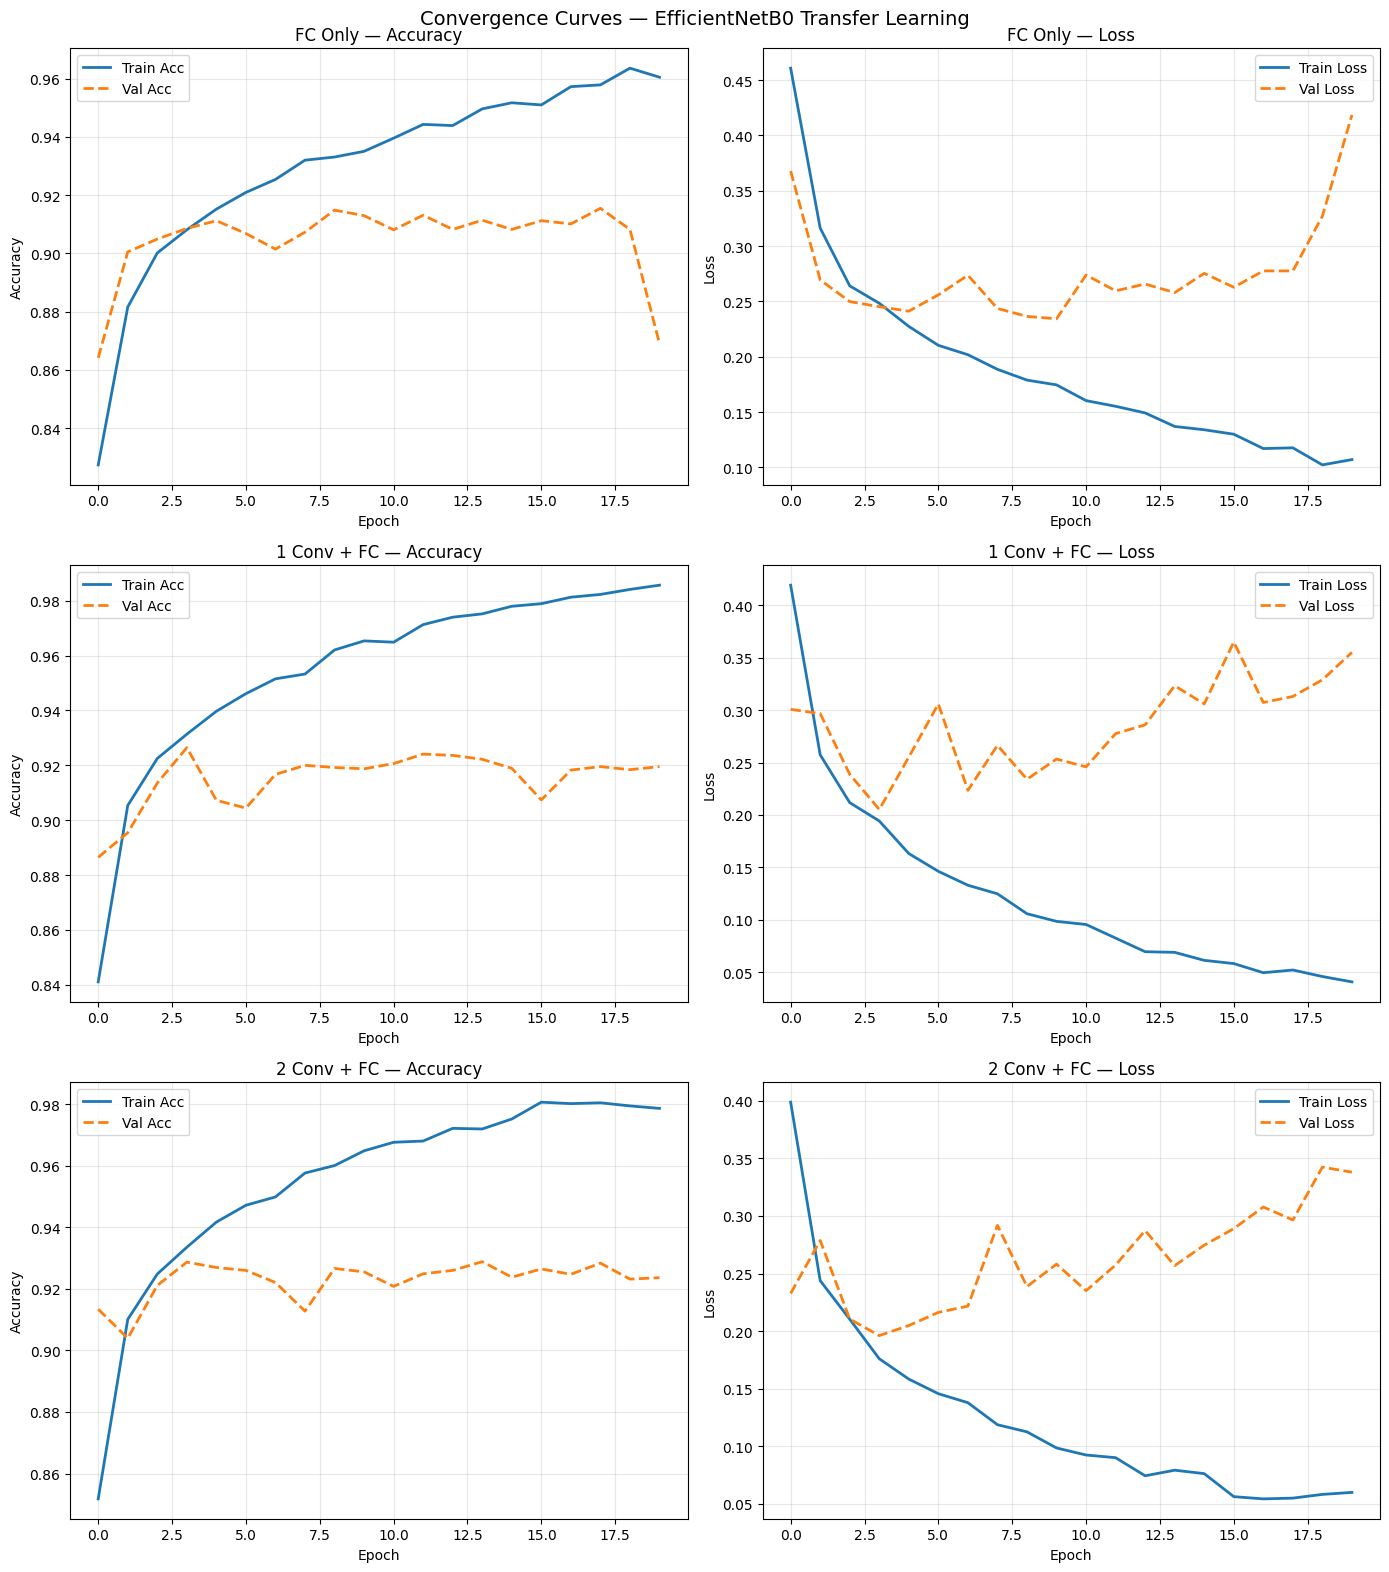

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt

# 1. Clear any old plots stuck in Kaggle's memory
plt.close('all') 

configs = [
    ("FC Only",     history_fc),
    ("1 Conv + FC", history_1conv_fc),
    ("2 Conv + FC", history_2conv_fc),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("Convergence Curves — EfficientNetB0 Transfer Learning", fontsize=14)

for row_idx, (config_label, hist) in enumerate(configs):
    h = hist.history

    ax_acc  = axes[row_idx][0]
    ax_loss = axes[row_idx][1]

    ax_acc.plot(h["accuracy"],     label="Train Acc",  linewidth=2)
    ax_acc.plot(h["val_accuracy"], label="Val Acc",    linewidth=2, linestyle="--")
    ax_acc.set_title(f"{config_label} — Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    ax_loss.plot(h["loss"],     label="Train Loss", linewidth=2)
    ax_loss.plot(h["val_loss"], label="Val Loss",   linewidth=2, linestyle="--")
    ax_loss.set_title(f"{config_label} — Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

# ---------------------------------------------------------
# CRITICAL: These must have NO spaces before them!
# If they have spaces, they are inside the loop.
# ---------------------------------------------------------
plt.tight_layout()
plt.show()

## Final Comparison Table

In [14]:
print("\n" + "="*78)
print("FINAL COMPARISON TABLE — EfficientNetB0 | Macro-averaged metrics")
print("="*78)
print(f"{'Config':<16} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} "
      f"{'F1-Score':>10} {'Sensitivity':>12} {'Time(s)':>10}")
print("-"*78)

for config_name, r in final_results.items():
    print(
        f"{config_name:<16} "
        f"{r['Accuracy']:>10.4f} "
        f"{r['Precision']:>10.4f} "
        f"{r['Recall']:>10.4f} "
        f"{r['F1-Score']:>10.4f} "
        f"{r['Sensitivity']:>12.4f} "
        f"{r['Train Time (s)']:>10.1f}"
    )

print("="*78)
print("Note: Sensitivity = Macro Recall (equal weight to all 4 classes)")


FINAL COMPARISON TABLE — EfficientNetB0 | Macro-averaged metrics
Config             Accuracy  Precision     Recall   F1-Score  Sensitivity    Time(s)
------------------------------------------------------------------------------
FC Only              0.8690     0.8771     0.9129     0.8893       0.9129      655.6
1 Conv + FC          0.9195     0.9314     0.9257     0.9283       0.9257      575.2
2 Conv + FC          0.9236     0.9360     0.9339     0.9348       0.9339      566.5
Note: Sensitivity = Macro Recall (equal weight to all 4 classes)
